In [2]:
import pandas as pd

data = pd.read_csv('superstore.csv')
data.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
data['Order.Date'] = pd.to_datetime(data['Order.Date'])
data = data.sort_values('Order.Date')

data = data.groupby('Order.Date')['Sales'].sum().reset_index()

data.head()

,Order.Date,Sales
0,2011-01-01,808
1,2011-01-02,314
2,2011-01-03,4502
3,2011-01-04,2809
4,2011-01-05,3664


In [17]:
import numpy as np

data['Days'] = np.arange(len(data))
data['DayOfWeek'] = data['Order.Date'].dt.dayofweek
data['Month'] = data['Order.Date'].dt.month

data.head()

,Order.Date,Sales,Days,DayOfWeek,Month
0,2011-01-01,808,0,5,1
1,2011-01-02,314,1,6,1
2,2011-01-03,4502,2,0,1
3,2011-01-04,2809,3,1,1
4,2011-01-05,3664,4,2,1


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = data[['Days', 'DayOfWeek', 'Month']]
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state =0
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("Model Error (MAE):", round(mae, 2))

Model trained successfully.
Model Error (MAE): 5214.87


In [25]:
data['Year'] = data['Order.Date'].dt.year
data['Month'] = data['Order.Date'].dt.month

data_2014 = data[data['Year'] == 2014]

monthly_sales = data_2014.groupby('Month')['Sales'].sum()

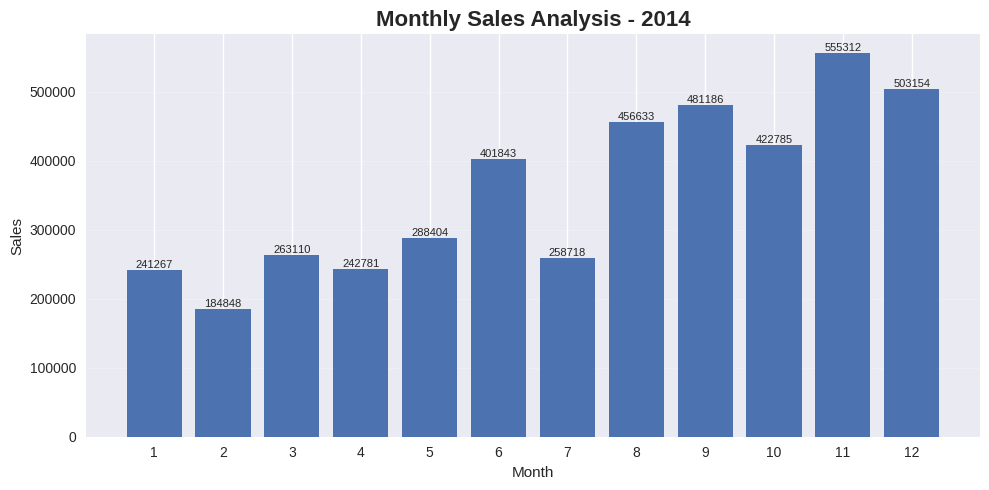

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Sales Analysis - 2014', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(range(1,13))
plt.grid(axis='y', alpha=0.2)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

for i, v in enumerate(monthly_sales.values):
    plt.text(i+1, v, str(int(v)), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [31]:
future_days = pd.DataFrame({
    'Days': [len(data)+1, len(data)+2, len(data)+3],
    'DayOfWeek': [(data['DayOfWeek'].iloc[-1] + i) % 7 for i in range(1,4)],
    'Month': [(data['Month'].iloc[-1] + i) % 12 for i in range(1,4)]
})

predictions = model.predict(future_days)

future_dates = pd.date_range(
    start=data['Order.Date'].iloc[-1],
    periods=4,
    freq='D'
)[1:]

print("Future Predictions:")
for date, pred in zip(future_dates, predictions):
    print(f"{date.date()} → {round(pred,2)} sales")

Future Predictions:
2015-01-01 → 8481.82 sales
2015-01-02 → 7851.25 sales
2015-01-03 → 7220.67 sales


### Insights from Sales Analysis

- Sales show a clear increasing trend over time, indicating business growth.
- Early months have lower sales compared to later months.
- Peak sales are observed in November, suggesting seasonal demand.
- Sales slightly drop after peak but remain higher than initial months.

### Model Insight

- The Linear Regression model captures the overall upward trend.
- The model provides reasonable future predictions but may not capture sudden spikes.